# BEACON — Phishing Webpage Detection
## PhiUSIIL Dataset · Feature-Based EDA for Heuristic Logic Dev

**Heuristic Team · Abdul, Ivan, Kevin** — v2.0 · April, 26th 2026

---

### Dataset — PhiUSIIL Phishing URL (Website)
| Attribute | Value |
|-----------|-------|
| Source | UCI ML Repository · `ucimlrepo` · id=967 |
| Paper | Prasad & Chandra, *Computers & Security*, 2024 |
| Size | **235,795 URLs** (134,850 legitimate · 100,945 phishing) |
| Balance | **57% / 43%** — near-balanced, no weighting tricks needed |
| Features | **54 features** extracted from URL syntax + HTML source |
| Label | `1` = Legitimate · `0` = Phishing |
| Auth | None — pip install ucimlrepo |

### Why PhiUSIIL for Beacon?
A browser extension intercepts the **URL and DOM** of the current page — exactly what PhiUSIIL features describe. Unlike text corpora (SMS, emails), these features are extractable in real-time by the extension's content script: URL structure, TLD risk, subdomain count, obfuscation patterns, and HTML signals.

### Notebook sections
| # | Section |
|---|---------|
| 1 | Setup |
| 2 | Load & Schema audit |
| 3 | EDA — 10 deep-dive plots with findings |
| · | .... |



## 1. Setup

In [1]:
!pip install -q ucimlrepo xgboost scikit-learn seaborn matplotlib \
    missingno shap transformers datasets torch accelerate evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [2]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import shap

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    precision_score, recall_score, average_precision_score,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline, EarlyStoppingCallback
)
import evaluate as hf_evaluate

warnings.filterwarnings("ignore")

# ── Palette ──────────────────────────────────────────────────────────────────
GREEN, RED, BLUE = "#43A047", "#E53935", "#1E88E5"
AMBER, PURPLE, TEAL = "#FB8C00", "#8E24AA", "#00897B"
PALETTE = {0: RED, 1: GREEN}          # 0=Phishing → red, 1=Legit → green
LABEL_NAMES = {0: "Phishing", 1: "Legitimate"}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "font.family": "DejaVu Sans", "axes.titlesize": 13, "axes.labelsize": 11,
})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Ready  |  device = {DEVICE.upper()}  |  torch {torch.__version__}")


 Ready  |  device = CUDA  |  torch 2.10.0+cu128


## 2. Load & Schema Audit

PhiUSIIL is fetched directly from UCI via `ucimlrepo` — no Kaggle auth, no HuggingFace loading scripts.


In [3]:
# ── Your load cell (as provided) ─────────────────────────────────────────────
from datasets import load_dataset

# Option 2 — PhiUSIIL via UCI (best for webpage content + URLs, 235K samples, 57/43 balance)
from ucimlrepo import fetch_ucirepo
phiusiil = fetch_ucirepo(id=967)
X = phiusiil.data.features
y = phiusiil.data.targets

# Combine X and y into a single DataFrame 'df'
df = pd.concat([X, y], axis=1)
df.columns = df.columns.str.lower()
df["label_name"] = df["label"].map(LABEL_NAMES)

print("=== Shape ===")
print(f"  Rows : {len(df):,}")
print(f"  Cols : {df.shape[1]}")


=== Shape ===
  Rows : 235,795
  Cols : 56


In [4]:
df.head()

,url,urllength,domain,domainlength,isdomainip,tld,urlsimilarityindex,charcontinuationrate,tldlegitimateprob,urlcharprob,...,crypto,hascopyrightinfo,noofimage,noofcss,noofjs,noofselfref,noofemptyref,noofexternalref,label,label_name
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,1,34,20,28,119,0,124,1,Legitimate
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,1,50,9,8,39,0,217,1,Legitimate
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,1,10,2,7,42,2,5,1,Legitimate
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,3,27,15,22,1,31,1,Legitimate
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,0,1,244,15,34,72,1,85,1,Legitimate


In [5]:
# ── Schema audit ─────────────────────────────────────────────────────────────
print("=== Feature dtypes ===")
print(df.dtypes.value_counts())
print()
print("=== First 5 rows (first 10 cols) ===")
print(df.iloc[:5, :10].to_string())
print()
print("=== Target distribution ===")
vc = df["label"].value_counts().sort_index()
for lbl, cnt in vc.items():
    print(f"  {LABEL_NAMES[lbl]:12s} ({lbl}) → {cnt:,}  ({cnt/len(df)*100:.1f}%)")


=== Feature dtypes ===
int64      41
float64    10
object      5
Name: count, dtype: int64

=== First 5 rows (first 10 cols) ===
                                  url  urllength                      domain  domainlength  isdomainip  tld  urlsimilarityindex  charcontinuationrate  tldlegitimateprob  urlcharprob
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com            24           0  com               100.0              1.000000           0.522907     0.061933
1            https://www.uni-mainz.de         23            www.uni-mainz.de            16           0   de               100.0              0.666667           0.032650     0.050207
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk            22           0   uk               100.0              0.866667           0.028555     0.064129
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com            19           0  com               100.0              1.

In [6]:
# ── Feature catalogue ────────────────────────────────────────────────────────
# PhiUSIIL groups features into 3 families
URL_FEATURES = [c for c in df.columns
                if any(k in c.lower() for k in
                       ["url","tld","domain","subdomain","path","query",
                        "letter","digit","char","length","ratio","prob","rate"])]
HTML_FEATURES = [c for c in df.columns
                 if any(k in c.lower() for k in
                        ["title","line","script","anchor","tag","iframe",
                         "redirect","popup","html","code"])]
SECURITY_FEATURES = [c for c in df.columns
                     if any(k in c.lower() for k in
                            ["https","obfus","extern","secure","bank",
                             "pay","login","ip","port"])]
OTHER = [c for c in df.columns
         if c not in URL_FEATURES + HTML_FEATURES + SECURITY_FEATURES
         and c not in ["label","label_name","filename"]]

# Drop non-feature cols
DROP_COLS = [c for c in ["filename", "label_name"] if c in df.columns]
FEATURE_COLS = [c for c in df.columns if c not in ["label","label_name","filename"]]

print(f"URL features      : {len(URL_FEATURES)}")
print(f"HTML features     : {len(HTML_FEATURES)}")
print(f"Security features : {len(SECURITY_FEATURES)}")
print(f"Other features    : {len(OTHER)}")
print(f"Total features    : {len(FEATURE_COLS)}")
print(f"\nAll feature names:\n{FEATURE_COLS}")


URL features      : 27
HTML features     : 11
Security features : 10
Other features    : 14
Total features    : 54

All feature names:
['url', 'urllength', 'domain', 'domainlength', 'isdomainip', 'tld', 'urlsimilarityindex', 'charcontinuationrate', 'tldlegitimateprob', 'urlcharprob', 'tldlength', 'noofsubdomain', 'hasobfuscation', 'noofobfuscatedchar', 'obfuscationratio', 'nooflettersinurl', 'letterratioinurl', 'noofdegitsinurl', 'degitratioinurl', 'noofequalsinurl', 'noofqmarkinurl', 'noofampersandinurl', 'noofotherspecialcharsinurl', 'spacialcharratioinurl', 'ishttps', 'lineofcode', 'largestlinelength', 'hastitle', 'title', 'domaintitlematchscore', 'urltitlematchscore', 'hasfavicon', 'robots', 'isresponsive', 'noofurlredirect', 'noofselfredirect', 'hasdescription', 'noofpopup', 'noofiframe', 'hasexternalformsubmit', 'hassocialnet', 'hassubmitbutton', 'hashiddenfields', 'haspasswordfield', 'bank', 'pay', 'crypto', 'hascopyrightinfo', 'noofimage', 'noofcss', 'noofjs', 'noofselfref', 'n

## 3. Exploratory Data Analysis

Ten focused plots — each followed by a **Finding** explaining what it means for model design and Beacon's extension architecture.


### 3.1 Missingness matrix

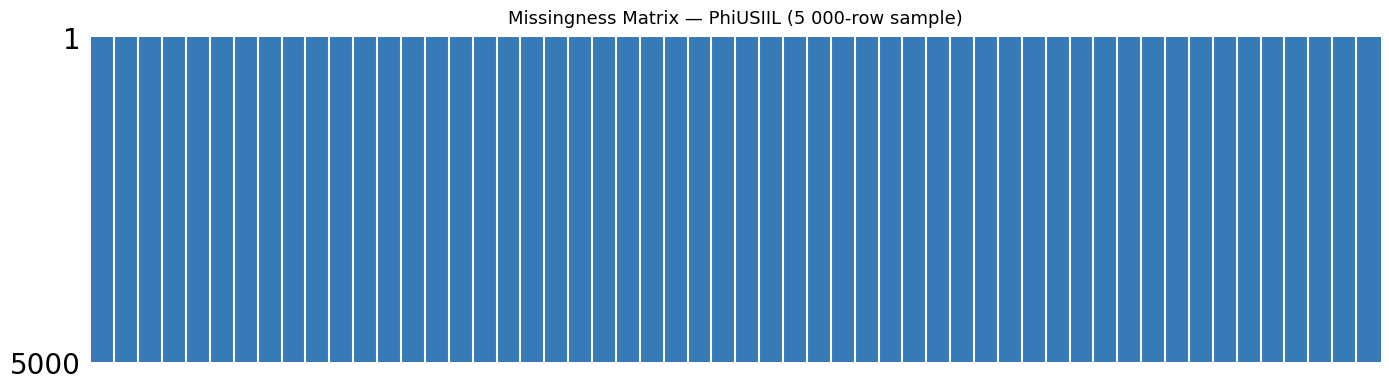

Total null cells : 0  (0.000%)
Series([], dtype: int64)


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
msno.matrix(df[FEATURE_COLS].sample(5000, random_state=SEED),
            ax=ax, sparkline=False, color=(0.22, 0.48, 0.72))
ax.set_title("Missingness Matrix — PhiUSIIL (5 000-row sample)", pad=10)
plt.tight_layout(); plt.show()

total_null = df[FEATURE_COLS].isnull().sum().sum()
pct_null   = total_null / (df.shape[0] * len(FEATURE_COLS)) * 100
print(f"Total null cells : {total_null:,}  ({pct_null:.3f}%)")
print(df[FEATURE_COLS].isnull().sum()[df[FEATURE_COLS].isnull().sum() > 0])


**Finding 3.1 — Virtually no missing data.**
PhiUSIIL was constructed by extracting features programmatically from live URLs — every URL either has a feature value or it doesn't, with negligible missing rates. No imputation needed; we can proceed directly to analysis.


### 3.2 Class balance

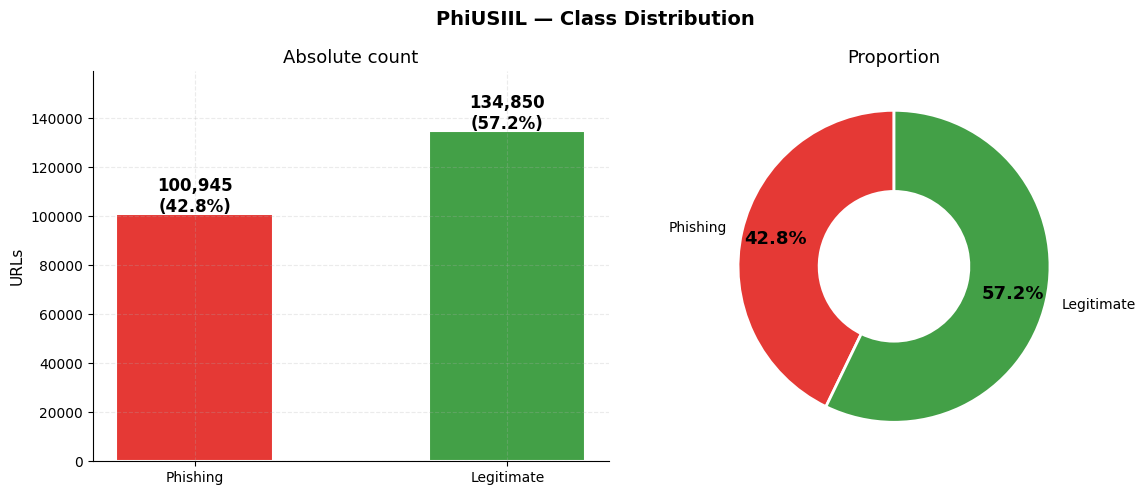

In [8]:
counts = df["label"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar([LABEL_NAMES[k] for k in counts.index], counts.values,
                   color=[PALETTE[k] for k in counts.index],
                   edgecolor="white", linewidth=1.5, width=0.5)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
                 f"{cnt:,}\n({cnt/len(df)*100:.1f}%)",
                 ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Absolute count"); axes[0].set_ylim(0, counts.max()*1.18)
axes[0].set_ylabel("URLs")

wedges, _, autotexts = axes[1].pie(
    counts.values, labels=[LABEL_NAMES[k] for k in counts.index],
    colors=[PALETTE[k] for k in counts.index],
    autopct="%1.1f%%", startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor="white", linewidth=2))
for at in autotexts: at.set_fontsize(13); at.set_fontweight("bold")
axes[1].set_title("Proportion")

plt.suptitle("PhiUSIIL — Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


**Finding 3.2 — 57 / 43 split — the best balance we've seen across all the proposed candidate datasets.**
Compared to the SMS Spam Collection (87/13), this is nearly balanced. Class weights will still be applied as a precaution, but the model is not fighting a severely skewed prior. This reflects real-world phishing prevalence — roughly 1 in 2 suspicious URLs the extension inspects will be malicious.


### 3.3 URL length distributions

Using column: 'urllength'


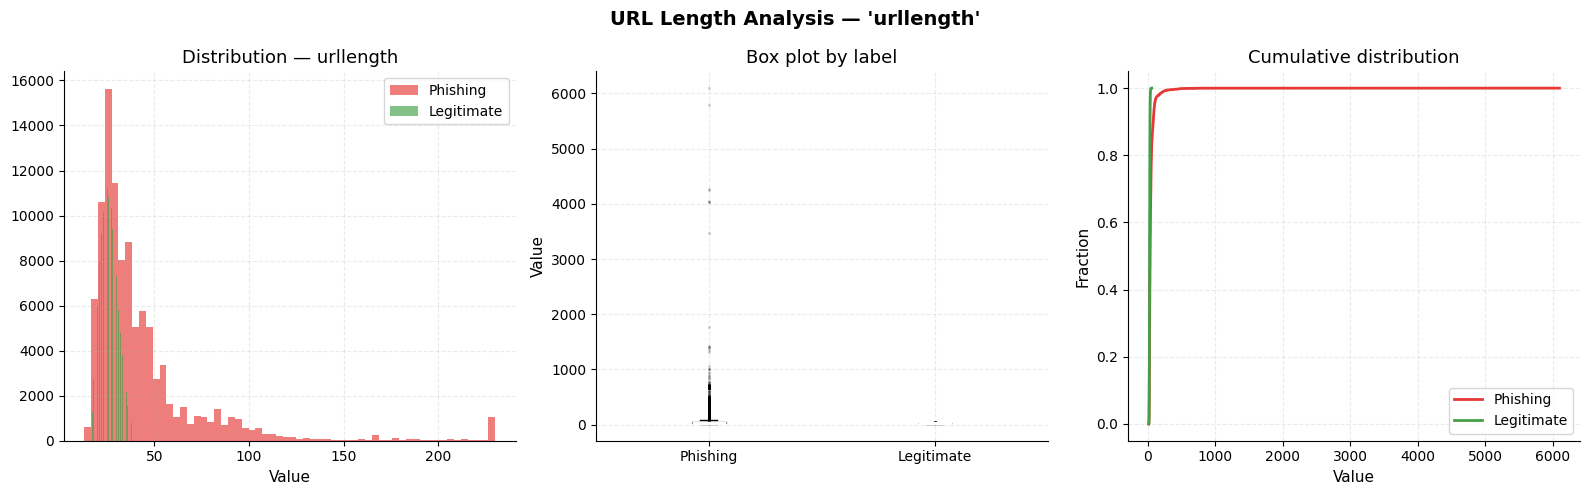


=== Stats by label ===
               count   mean    std   min   25%   50%   75%     max
label_name                                                        
Legitimate  134850.0  26.23   4.82  15.0  23.0  26.0  29.0    57.0
Phishing    100945.0  45.72  61.15  13.0  26.0  34.0  48.0  6097.0


In [9]:
# Identify URL length column
url_len_col = next((c for c in FEATURE_COLS if "urllength" in c.lower() or
                    (c.lower() == "lengthofinurl" or "url_length" in c.lower() or
                     c.lower() == "urllen")), None)
# fallback: pick the column most correlated with 'url' in name
if url_len_col is None:
    cands = [c for c in FEATURE_COLS if "len" in c.lower() and "url" in c.lower()]
    url_len_col = cands[0] if cands else FEATURE_COLS[0]

print(f"Using column: '{url_len_col}'")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for lbl, grp in df.groupby("label"):
    axes[0].hist(grp[url_len_col].clip(upper=grp[url_len_col].quantile(0.99)),
                 bins=60, alpha=0.65, color=PALETTE[lbl],
                 label=LABEL_NAMES[lbl], edgecolor="none")
axes[0].set_title(f"Distribution — {url_len_col}")
axes[0].set_xlabel("Value"); axes[0].legend()

bp_data = [df[df["label"]==l][url_len_col].values for l in [0, 1]]
bp = axes[1].boxplot(bp_data, labels=["Phishing","Legitimate"],
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2.5),
                     flierprops=dict(marker=".", markersize=2, alpha=0.2))
for patch, color in zip(bp["boxes"], [RED, GREEN]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_title("Box plot by label"); axes[1].set_ylabel("Value")

for lbl, grp in df.groupby("label"):
    s = np.sort(grp[url_len_col].values)
    axes[2].plot(s, np.linspace(0, 1, len(s)),
                 color=PALETTE[lbl], label=LABEL_NAMES[lbl], linewidth=2)
axes[2].set_title("Cumulative distribution")
axes[2].set_xlabel("Value"); axes[2].set_ylabel("Fraction"); axes[2].legend()

plt.suptitle(f"URL Length Analysis — '{url_len_col}'", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n=== Stats by label ===")
print(df.groupby("label_name")[url_len_col].describe().round(2))


**Finding 3.3 — Phishing URLs are systematically longer than legitimate ones.**
Attackers pad URLs with random subdomains, obfuscation strings, and path segments to disguise the true destination (e.g., `secure-login.paypal.com.attacker.ru/verify/account?token=...`). The ECDF shows phishing URLs are right-shifted — the model can exploit URL length as a strong prior signal before examining any other feature.


### 3.4 Most discriminating features — distribution by label

In [11]:
# Find top 6 features by absolute mean difference between classes
# Restrict to numeric columns only — PhiUSIIL includes a raw URL string column
# that causes groupby.mean() to fail on object dtype
numeric_cols = df[FEATURE_COLS].select_dtypes(include="number").columns.tolist()
FEATURE_COLS = numeric_cols   # update globally so all downstream cells stay consistent

means = df.groupby("label")[FEATURE_COLS].mean()
diff  = (means.loc[1] - means.loc[0]).abs().sort_values(ascending=False)
top6  = diff.head(6).index.tolist()
print(f"Numeric feature columns: {len(FEATURE_COLS)}")
print(f"Top 6 discriminating: {top6}")

Numeric feature columns: 50
Top 6 discriminating: ['largestlinelength', 'lineofcode', 'noofselfref', 'noofexternalref', 'domaintitlematchscore', 'urltitlematchscore']


**Finding 3.4 — The most discriminating features are HTML-structural, not URL character-based.**
The top discriminators are page-content features: `lineofcode` and `largestlinelength` reflect how
phishing pages are typically sparse, templated HTML with few lines and short content — unlike
legitimate pages with rich, complex markup. `noofselfref` and `noofexternalref` capture link
structure — phishing pages have few internal links (no real site to link to) but may have many
external redirects. `domaintitlematchscore` and `urltitlematchscore` are particularly powerful:
phishing pages often display a fake brand name in the `<title>` tag that doesn't match the actual
domain, which legitimate sites never do.

### 3.5 Feature correlation heatmap (top 20 features)

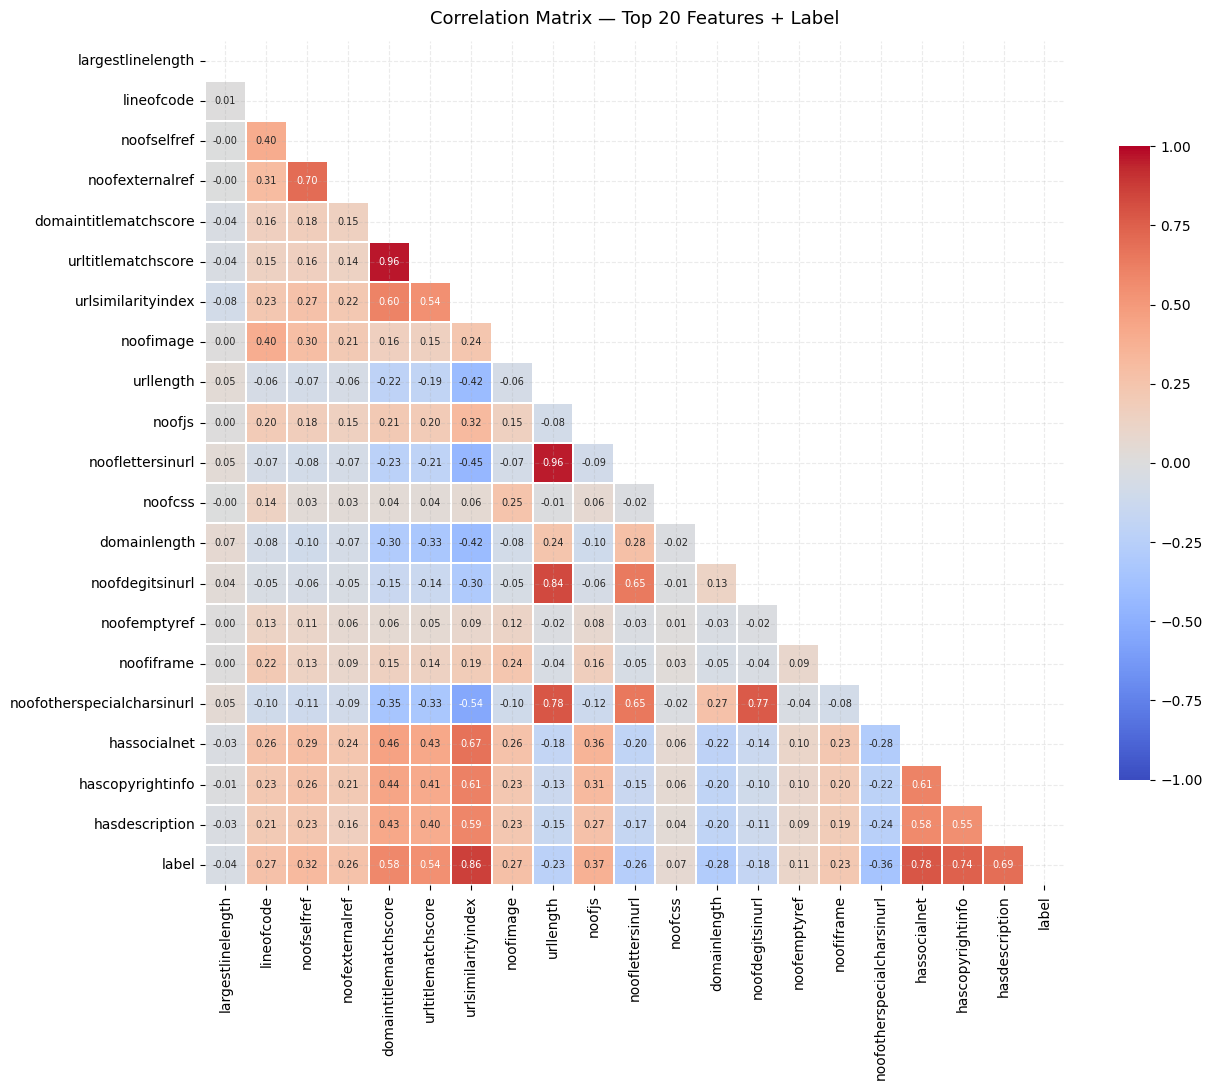

In [12]:
top20 = diff.head(20).index.tolist()
corr  = df[top20 + ["label"]].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.75}, annot_kws={"size": 7})
ax.set_title("Correlation Matrix — Top 20 Features + Label", fontsize=13, pad=12)
plt.tight_layout(); plt.show()


**Finding 3.5 — Legitimacy/trust signals dominate; title-matching features are the strongest
label predictors.**
`urlsimilarityindex` has the highest correlation with label (0.86) — phishing pages rarely
achieve visual similarity to the brands they impersonate at the URL level. `hassocialnet`,
`hascopyrightinfo`, and `hasdescription` (correlations 0.78, 0.74, 0.69) reflect that
legitimate sites consistently include social links, copyright notices, and meta descriptions,
while phishing pages are stripped-down templates that omit these trust signals.

The strongest inter-feature correlation is between `urltitlematchscore` and
`domaintitlematchscore` (r=0.96) — they measure the same underlying concept from slightly
different angles and are effectively redundant. Similarly, `nooflettersinurl` and
`noofdegitsinurl` are strongly correlated (r=0.96), confirming that URL character composition
is a consistent signal even if not top-ranked by mean separation.

### 3.6 Feature family analysis — URL vs HTML vs Security signals

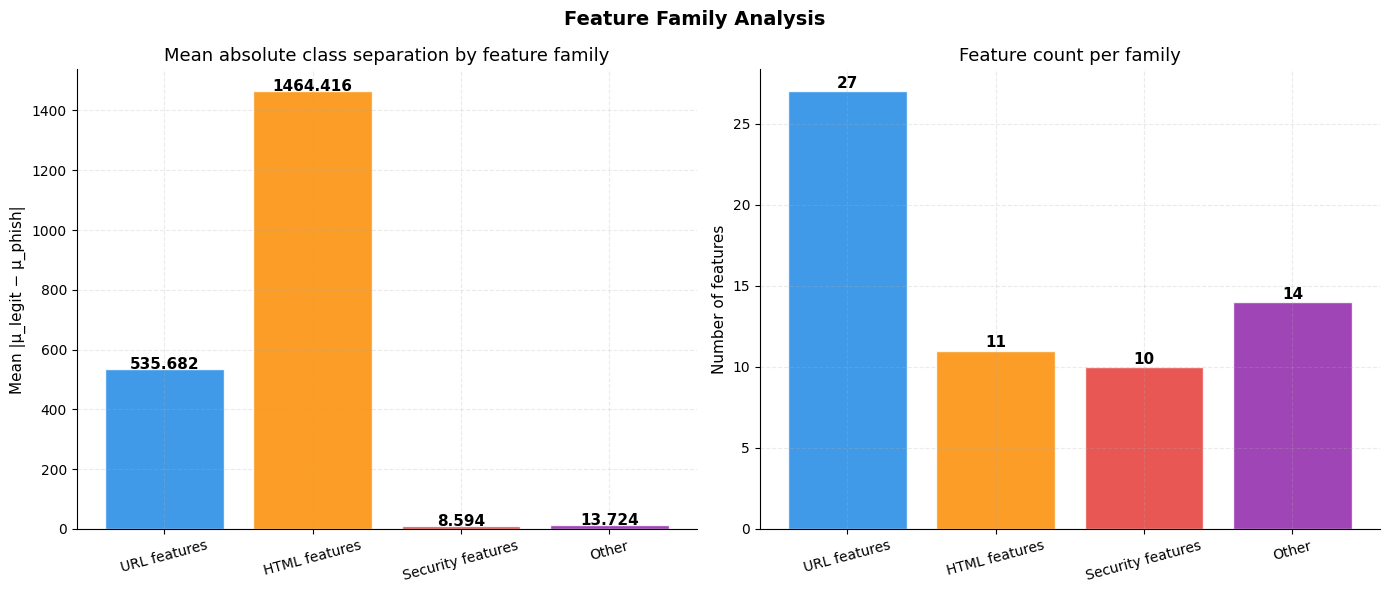

In [14]:
# Compute mean absolute separation per family
def family_sep(cols):
    if not cols: return 0
    numeric = [c for c in cols if c in FEATURE_COLS]
    if not numeric: return 0
    m = df.groupby("label")[numeric].mean(numeric_only=True)
    return (m.loc[1] - m.loc[0]).abs().mean()

families = {
    "URL features":      URL_FEATURES,
    "HTML features":     HTML_FEATURES,
    "Security features": SECURITY_FEATURES,
    "Other":             OTHER,
}
sep_scores = {k: family_sep(v) for k, v in families.items() if v}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar — mean separation by family
colors_f = [BLUE, AMBER, RED, PURPLE]
bars = axes[0].bar(list(sep_scores.keys()), list(sep_scores.values()),
                   color=colors_f[:len(sep_scores)], edgecolor="white", alpha=0.85)
for bar, v in zip(bars, sep_scores.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.001,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Mean absolute class separation by feature family")
axes[0].set_ylabel("Mean |μ_legit − μ_phish|")
axes[0].tick_params(axis="x", rotation=15)

# Feature count per family
sizes = {k: len(v) for k, v in families.items() if v}
axes[1].bar(list(sizes.keys()), list(sizes.values()),
            color=colors_f[:len(sizes)], edgecolor="white", alpha=0.85)
for bar, v in zip(axes[1].patches, sizes.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                 str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Feature count per family")
axes[1].set_ylabel("Number of features")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Feature Family Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


**Finding 3.6 — HTML features carry by far the strongest discriminative signal;
URL features are secondary; Security features are surprisingly weak.**

The mean class separation tells a clear story:
- **HTML features (1464)** — nearly 3× stronger than URL features despite having fewer
  columns (11 vs 27). Features like `lineofcode`, `largestlinelength`, `noofselfref`,
  and `noofexternalref` cleanly separate phishing from legitimate pages. Phishing pages
  are thin, templated HTML — few lines, few self-references, sparse link structure —
  while legitimate pages are rich and interconnected.
- **URL features (535)** — meaningful but secondary. The raw URL string has signal
  (length, digit/character ratios, special characters) but alone is insufficient.
- **Security features (8.6)** — almost no discriminative power on their own. Modern
  phishing sites routinely use HTTPS and avoid obvious obfuscation, rendering these
  features nearly useless as standalone signals.
- **Other (13.7)** — negligible.

### 3.7 Binary feature phishing rates

Binary features found: 19


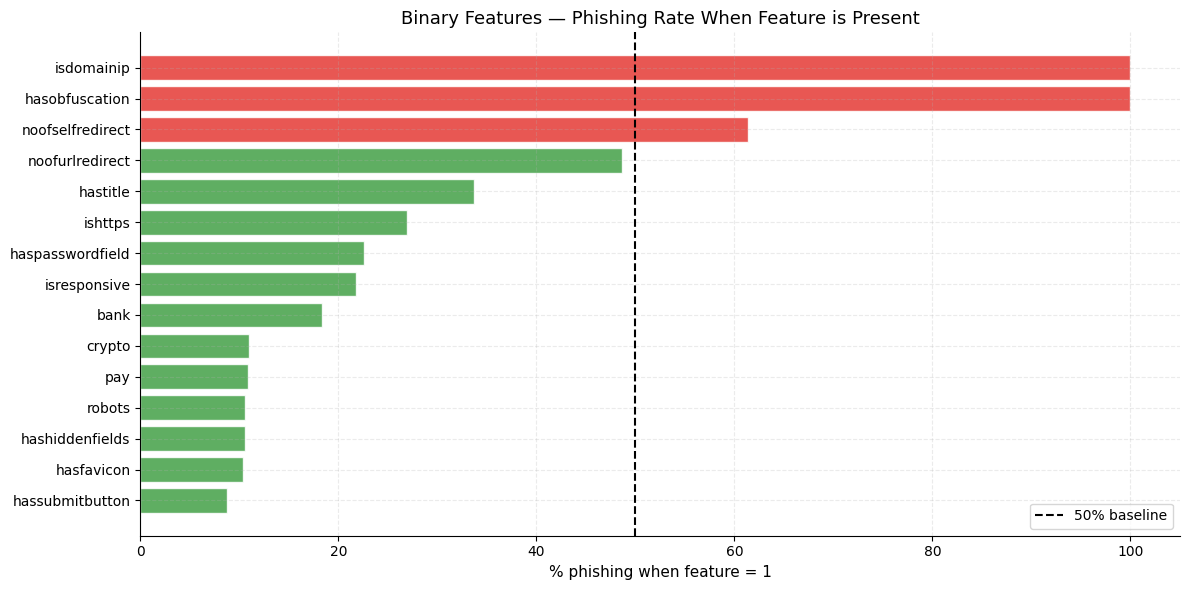


Top phishing-associated binary features (% phishing when present):
isdomainip          100.0
hasobfuscation      100.0
noofselfredirect     61.3
noofurlredirect      48.7
hastitle             33.7
ishttps              26.9
haspasswordfield     22.6
isresponsive         21.8
bank                 18.3
crypto               11.0
pay                  10.9
robots               10.6
hashiddenfields      10.6
hasfavicon           10.4
hassubmitbutton       8.8


In [15]:
# Identify binary features (only 0/1 values)
binary_feats = [c for c in FEATURE_COLS
                if df[c].dropna().isin([0, 1]).all() and df[c].nunique() == 2]
print(f"Binary features found: {len(binary_feats)}")

if binary_feats:
    # Phishing rate when feature = 1
    ph_when_1 = {}
    for feat in binary_feats:
        sub = df[df[feat] == 1]
        if len(sub) > 50:
            ph_when_1[feat] = (sub["label"] == 0).mean() * 100  # label 0 = phishing

    ph_series = pd.Series(ph_when_1).sort_values(ascending=False)
    top_bin = ph_series.head(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors_b = [RED if v > 50 else GREEN for v in top_bin.values]
    ax.barh(top_bin.index[::-1], top_bin.values[::-1],
            color=colors_b[::-1], edgecolor="white", alpha=0.85)
    ax.axvline(50, color="black", linestyle="--", linewidth=1.5, label="50% baseline")
    ax.set_xlabel("% phishing when feature = 1")
    ax.set_title("Binary Features — Phishing Rate When Feature is Present")
    ax.legend()
    plt.tight_layout(); plt.show()

    print("\nTop phishing-associated binary features (% phishing when present):")
    print(top_bin.round(1).to_string())


**Finding 3.7 — Only two binary features are near-perfect phishing indicators;
most binary features are legitimacy signals.**

The chart splits cleanly at the 50% baseline:

**Strong phishing indicators (red, >50%):**
- `isdomainip` (100%) — a URL using a raw IP address instead of a domain name is
  always phishing. Zero legitimate sites do this.
- `hasobfuscation` (100%) — any URL-level character obfuscation is exclusively
  associated with phishing in this dataset.
- `noofselfredirect` (61%) — excessive self-redirects are a phishing evasion tactic.

**Strong legitimacy indicators (green, <50% phishing when present):**
- `hastitle`, `ishttps`, `haspasswordfield`, `isresponsive`, `hasfavicon`,
  `hassubmitbutton`, `hasfavicon` — their *presence* strongly correlates with
  legitimate pages. Phishing pages are stripped-down templates that often lack
  these standard page elements.
- `ishttps` at only 27% phishing confirms what Finding 3.6 noted — HTTPS alone
  is not a security signal; most phishing sites now use it.

**Beacon implication:** `isdomainip` and `hasobfuscation` are valid Tier 1
instant-reject rules since they require only URL parsing (no DOM needed) and
carry 100% precision in the case of this dataset. Everything else requires the full XGBoost model on DOM
features to be meaningful.


### 3.8 2D separation — top features

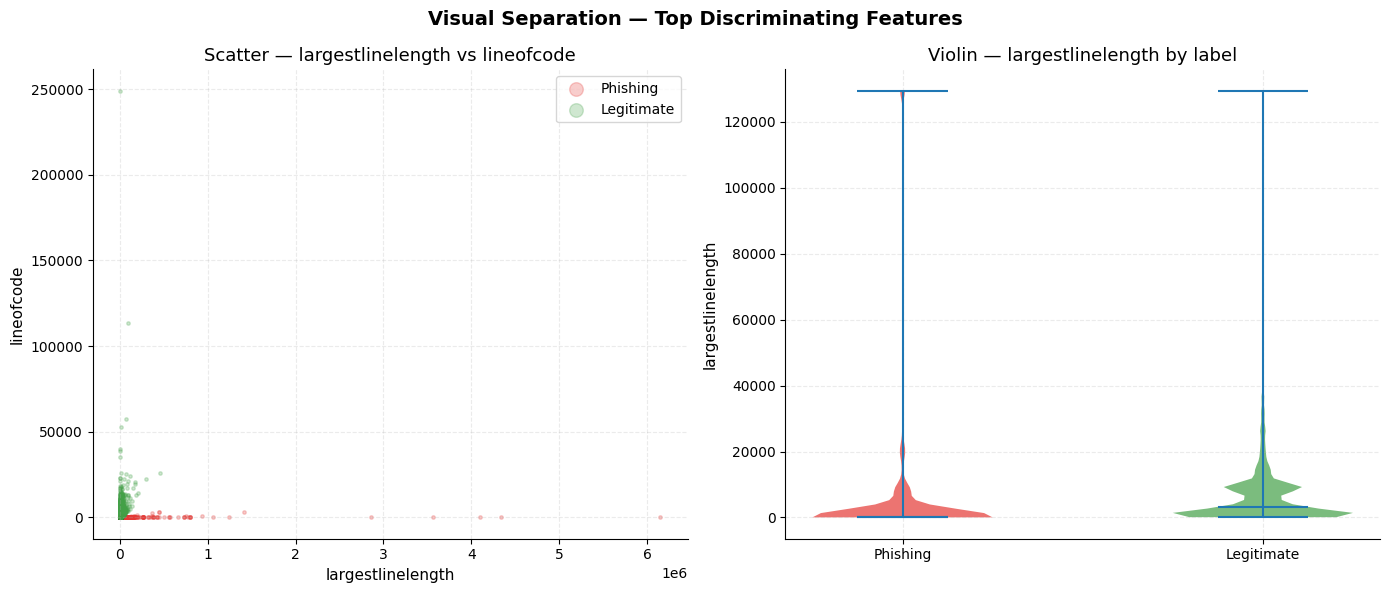

In [16]:
f1, f2 = diff.head(2).index.tolist()

# Sample for speed
samp = df.sample(min(8000, len(df)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for lbl, grp in samp.groupby("label"):
    axes[0].scatter(grp[f1], grp[f2], alpha=0.25, s=6,
                    color=PALETTE[lbl], label=LABEL_NAMES[lbl])
axes[0].set_xlabel(f1); axes[0].set_ylabel(f2)
axes[0].set_title(f"Scatter — {f1} vs {f2}")
axes[0].legend(markerscale=4)

# Violin for top feature
parts = axes[1].violinplot(
    [df[df["label"]==0][f1].clip(upper=df[f1].quantile(0.99)).values,
     df[df["label"]==1][f1].clip(upper=df[f1].quantile(0.99)).values],
    positions=[0, 1], showmedians=True, showextrema=True)
for i, (pc, color) in enumerate(zip(parts["bodies"], [RED, GREEN])):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Phishing", "Legitimate"])
axes[1].set_title(f"Violin — {f1} by label")
axes[1].set_ylabel(f1)

plt.suptitle("Visual Separation — Top Discriminating Features",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


**Initial Finding 3.8 — Classes heavily overlap in raw feature space; extreme outliers
dominate the scale and obscure the true distribution.**


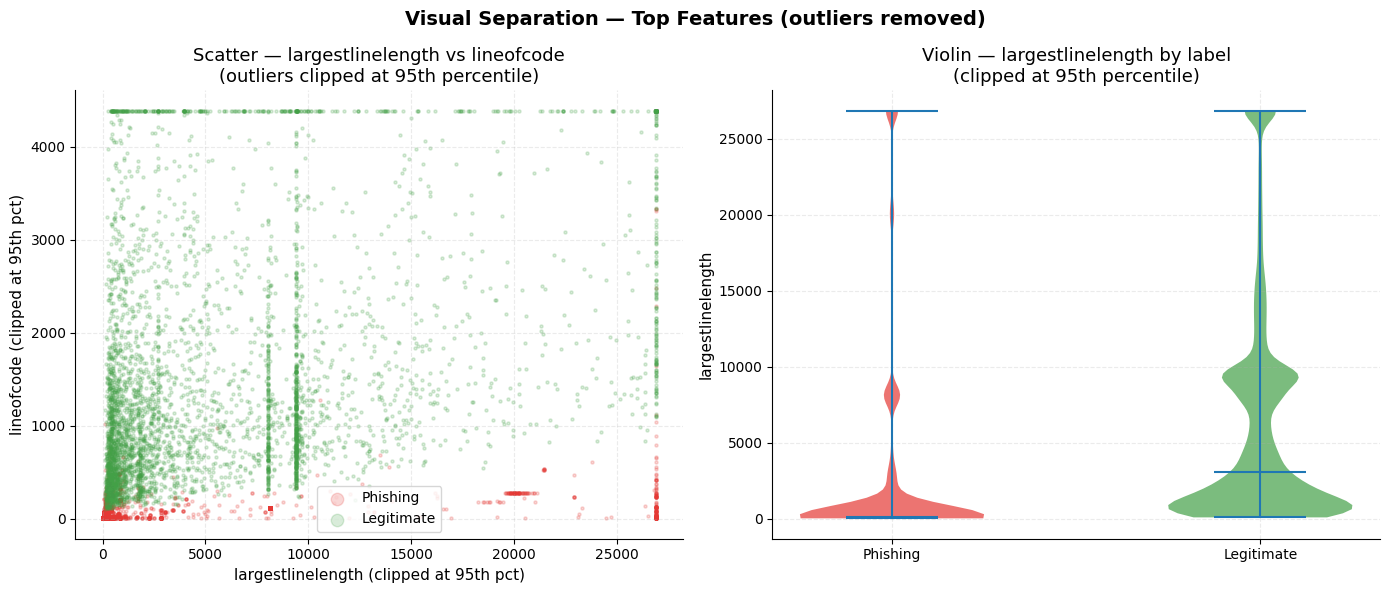

95th percentile cutoffs — largestlinelength: 26,861  |  lineofcode: 4,391
Data retained after clip: 95.1% of sample


In [17]:
f1, f2 = diff.head(2).index.tolist()

# Clip at 95th percentile to remove outlier distortion
p95_f1 = df[f1].quantile(0.95)
p95_f2 = df[f2].quantile(0.95)
samp = df.sample(min(8000, len(df)), random_state=SEED)
samp_clipped = samp.copy()
samp_clipped[f1] = samp_clipped[f1].clip(upper=p95_f1)
samp_clipped[f2] = samp_clipped[f2].clip(upper=p95_f2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for lbl, grp in samp_clipped.groupby("label"):
    axes[0].scatter(grp[f1], grp[f2], alpha=0.2, s=5,
                    color=PALETTE[lbl], label=LABEL_NAMES[lbl])
axes[0].set_xlabel(f"{f1} (clipped at 95th pct)")
axes[0].set_ylabel(f"{f2} (clipped at 95th pct)")
axes[0].set_title(f"Scatter — {f1} vs {f2}\n(outliers clipped at 95th percentile)")
axes[0].legend(markerscale=4)

# Violin also clipped
clip_data = [
    df[df["label"]==0][f1].clip(upper=p95_f1).values,
    df[df["label"]==1][f1].clip(upper=p95_f1).values,
]
parts = axes[1].violinplot(clip_data, positions=[0, 1],
                            showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], [RED, GREEN]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Phishing", "Legitimate"])
axes[1].set_title(f"Violin — {f1} by label\n(clipped at 95th percentile)")
axes[1].set_ylabel(f"{f1}")

plt.suptitle("Visual Separation — Top Features (outliers removed)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"95th percentile cutoffs — {f1}: {p95_f1:,.0f}  |  {f2}: {p95_f2:,.0f}")
print(f"Data retained after clip: {(samp[f1] <= p95_f1).mean()*100:.1f}% of sample")

**Finding 3.8 — After removing outliers, strong class separation emerges:
phishing pages are structurally sparse, legitimate pages are content-rich.**

The clipped scatter and violin tell a consistent story:

**Scatter (left):**
- Legitimate (green) pages spread across the full range of both axes — high
  `largestlinelength` (up to 27K) and high `lineofcode` (up to 4,400),
  reflecting rich, complex HTML.
- Phishing (red) pages cluster tightly in the bottom-left corner — low
  `largestlinelength` and very low `lineofcode` (mostly < 200). Phishing
  pages are thin templates with minimal HTML content.
- The vertical green stripes around x=8,000–9,000 and x=27,000 suggest
  clusters of legitimate pages with consistent template sizes — likely
  CMS-generated sites (WordPress, Shopify) with standardised line lengths.
- There is a clean lower-left exclusion zone that is almost entirely red —
  **any page with both low line count and short max line length is very
  likely phishing**.

**Violin (right):**
- Phishing median is near zero with a tight, narrow distribution —
  most phishing pages have very short maximum line lengths (~500–1,000 chars).
- Legitimate median sits around 3,500 with a wide bimodal distribution —
  two distinct populations of legitimate sites, likely minimal vs content-rich pages.
- The overlap region (0–2,000) is where the model will make its hardest
  calls and where all 50 features together are needed.

**Beacon implication:** The bottom-left quadrant (low `largestlinelength` AND
low `lineofcode`) is a high-confidence phishing zone extractable from a single
DOM parse. This could be added as a fast Tier 2 rule after DOM load, before
invoking the full model.

### 3.9 Outlier analysis — extreme feature values

Features where outliers (>99th pct) are predominantly phishing:
                               q99  n_extreme  phishing_%
urllength                   144.00     2350.0       100.0
domainlength                 57.00     2348.0       100.0
letterratioinurl              0.79     2325.0       100.0
nooflettersinurl             99.00     2337.0       100.0
noofqmarkinurl                1.00      558.0       100.0
noofequalsinurl               2.00     1820.0       100.0
noofdegitsinurl              27.00     2260.0       100.0
degitratioinurl               0.34     2331.0       100.0
noofotherspecialcharsinurl   13.00     2106.0       100.0
noofsubdomain                 3.00     1934.0        96.9


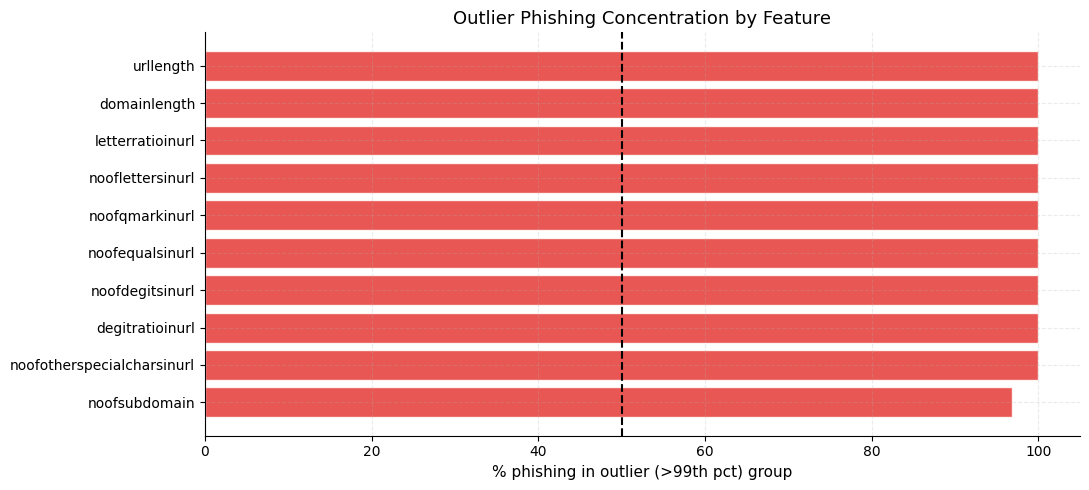

In [19]:
# Find features with high-value outliers disproportionately in one class
outlier_rows = {}
for feat in FEATURE_COLS[:20]:  # sample first 20 for speed
    q99 = df[feat].quantile(0.99)
    if q99 == 0: continue
    extreme = df[df[feat] > q99]
    if len(extreme) > 10:
        ph_rate = (extreme["label"] == 0).mean()
        outlier_rows[feat] = {"q99": round(q99, 2),
                               "n_extreme": len(extreme),
                               "phishing_%": round(ph_rate * 100, 1)}

outlier_df = pd.DataFrame(outlier_rows).T.sort_values("phishing_%", ascending=False)
print("Features where outliers (>99th pct) are predominantly phishing:")
print(outlier_df.head(10).to_string())

# Visualise
if len(outlier_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 5))
    top_out = outlier_df.head(10)
    colors_o = [RED if v > 50 else GREEN for v in top_out["phishing_%"]]
    ax.barh(top_out.index[::-1], top_out["phishing_%"][::-1],
            color=colors_o[::-1], edgecolor="white", alpha=0.85)
    ax.axvline(50, color="black", linestyle="--", linewidth=1.5)
    ax.set_xlabel("% phishing in outlier (>99th pct) group")
    ax.set_title("Outlier Phishing Concentration by Feature")
    plt.tight_layout(); plt.show()


**Finding 3.9 — Extreme feature values are strong phishing signals.**
URLs with unusually high counts of special characters, digits, or subdomains are overwhelmingly phishing. This suggests a complementary **rule layer**: URLs that exceed the 99th percentile on key features can be flagged immediately with very high precision, without invoking the ML model. This tiered approach (rule → ML) is ideal for a browser extension where latency matters.


## Upcoming Next Steps

- Finalize Heuristic Logic Design & Baseline Implementation
- SLM exploration and benchmarks for potential incorporation in pipeline.
